In [5]:
# Run 'pip install -r requirements.txt' to install the necessary libraries
import pandas as pd
import numpy as np

Clean the data by removing unnecesary columns

In [6]:
file_path = "OnlineNewsPopularity.csv"
df = pd.read_csv(file_path)

# print("Dataset Info:")
# print(df.info())

# print("\nFirst few rows:")
# print(df.head())

# Remove the spaces at the start of each column name
df.columns = df.columns.str.strip()


# Drop unwanted columns
columns_to_remove = ["url", "timedelta", "LDA_00", "LDA_01", "LDA_02", "LDA_03", "LDA_04"]
df_cleaned = df.drop(columns=columns_to_remove)

# print("\nColumns after removal:")
# print(df_cleaned.columns)

# Check for missing values
# missing_values = df_cleaned.isnull().sum()
# print("\nMissing Values:")
# print(missing_values[missing_values > 0])  # Only display columns with missing values

# Summary statistics
# print("\nSummary Statistics:")
# print(df_cleaned.describe())

print(f"Shape of data before cleaning: {df.shape}")
print(f"Shape of data after cleaning: {df_cleaned.shape}")


Shape of data before cleaning: (39644, 61)
Shape of data after cleaning: (39644, 54)


Add a "popularity" column, based on the number of shares an article has.

In [7]:
low_threshold = df_cleaned["shares"].quantile(0.31)
high_threshold = df_cleaned["shares"].quantile(0.67)

# Create the popularity category
def classify_popularity(shares):
    if shares <= low_threshold:
        return "low"
    elif shares <= high_threshold:
        return "medium"
    else:
        return "high"

df_cleaned["popularity"] = df_cleaned["shares"].apply(classify_popularity)

# Verify the distribution
print(df_cleaned["popularity"].value_counts())

print(f"\nAfter adding this new column called 'popularity', the shape of the data is: ")
print(df_cleaned.shape)

print(f"\nAn article is considered low popularity if it less than {low_threshold} shares")
print(f"An article is considered medium popularity if it has {low_threshold} - {high_threshold} shares")
print(f"An article is considered high popularity if it has more than {high_threshold} shares")

popularity
medium    14265
high      12955
low       12424
Name: count, dtype: int64

After adding this new column called 'popularity', the shape of the data is: 
(39644, 55)

An article is considered low popularity if it less than 1000.0 shares
An article is considered medium popularity if it has 1000.0 - 2100.0 shares
An article is considered high popularity if it has more than 2100.0 shares


Standardize the raw features

In [8]:
features = df_cleaned.drop(columns=["shares", "popularity"])

means = features.mean()
std_devs = features.std()

df_standardized = (features - means) / std_devs

df_standardized.columns = features.columns

# Verify standardization
standardized_means = df_standardized.mean()
standardized_std_devs = df_standardized.std()

print("Feature-wise Mean After Standardization (should be ~0):")
print(standardized_means)
print("\nFeature-wise Std Dev After Standardization (should be ~1):")
print(standardized_std_devs)


Feature-wise Mean After Standardization (should be ~0):
n_tokens_title                   4.014771e-16
n_tokens_content                 7.187157e-17
n_unique_tokens                 -1.003693e-17
n_non_stop_words                -2.150770e-18
n_non_stop_unique_tokens         2.222462e-17
num_hrefs                        7.742772e-17
num_self_hrefs                  -1.720616e-17
num_imgs                        -5.735387e-18
num_videos                       1.290462e-17
average_token_length             1.376493e-16
num_keywords                     1.147077e-16
data_channel_is_lifestyle        6.595695e-17
data_channel_is_entertainment   -8.603080e-17
data_channel_is_bus             -5.735387e-18
data_channel_is_socmed          -6.308926e-17
data_channel_is_tech             4.588309e-17
data_channel_is_world            0.000000e+00
kw_min_min                       2.294155e-17
kw_max_min                      -4.301540e-18
kw_avg_min                      -4.588309e-17
kw_min_max              

Perform k-means clustering for different values of k


For k = 2:
Cluster 0: 24456 points
Cluster 1: 15188 points


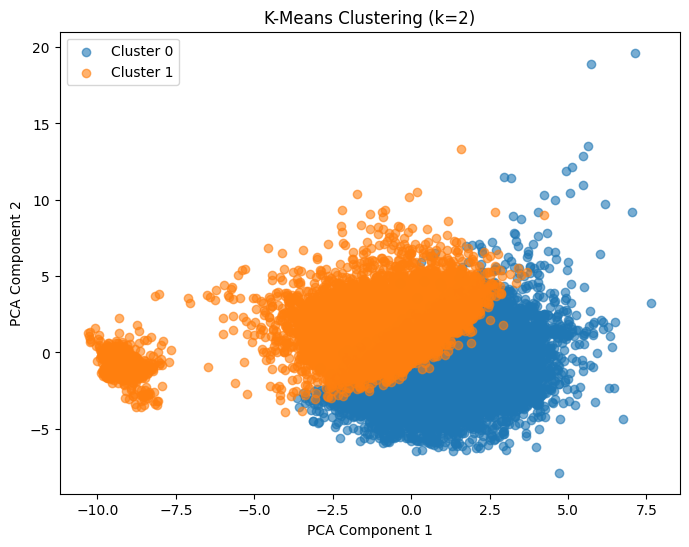


For k = 3:
Cluster 0: 14993 points
Cluster 1: 11188 points
Cluster 2: 13463 points


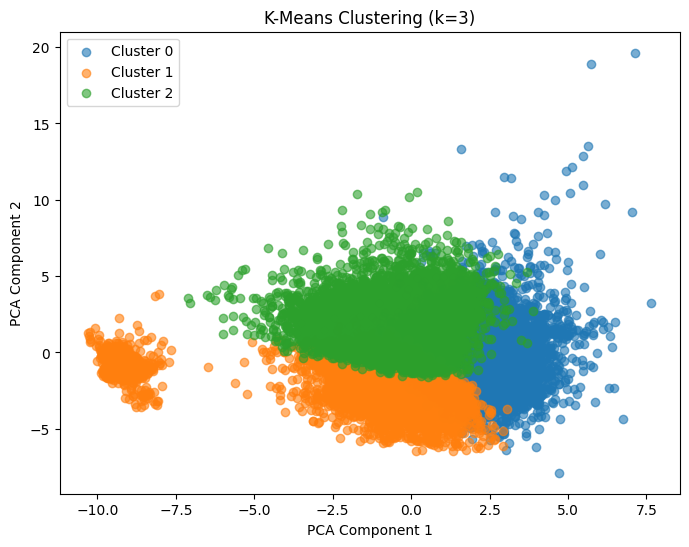


For k = 4:
Cluster 0: 15211 points
Cluster 1: 1184 points
Cluster 2: 12420 points
Cluster 3: 10829 points


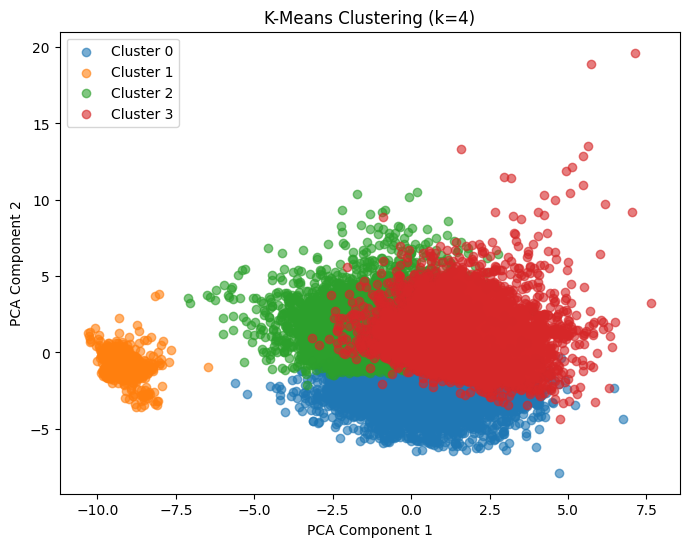


For k = 5:
Cluster 0: 13765 points
Cluster 1: 1184 points
Cluster 2: 11019 points
Cluster 3: 9371 points
Cluster 4: 4305 points


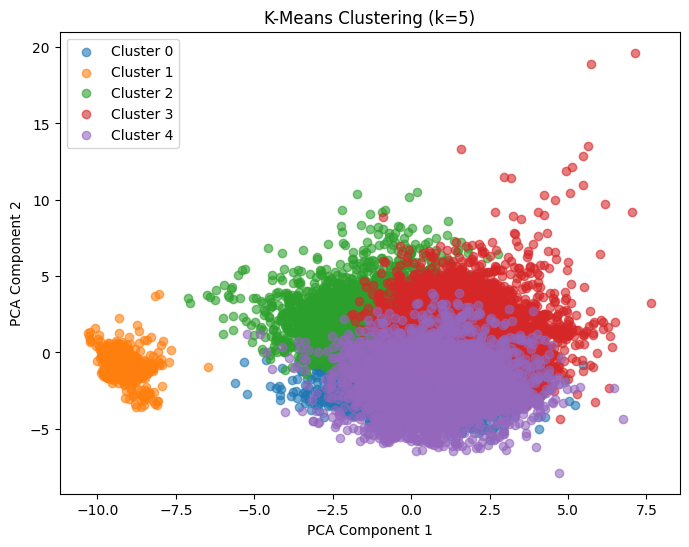

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Function to calculate euclidean distance
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=1))


# Function to perform k-means clustering for a given value of k
def k_means(X, k, max_iters=100, tol=1e-4):
    # Randomly initialize k centroids
    # For reproducibility, do np.random.seed() with the same integer
    np.random.seed(42)
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        # Assign each point to the nearest centroid
        distances = np.array([euclidean_distance(X, c) for c in centroids])
        labels = np.argmin(distances, axis=0)

        # Compute new centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        # Check for convergence
        if np.max(np.linalg.norm(new_centroids - centroids, axis=1)) < tol:
            break
        centroids = new_centroids

    return labels, centroids


def plot_clusters(X, labels, k):
    pca = PCA(n_components=2)  # Reduce to 2D
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    for i in range(k):
        plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1], label=f'Cluster {i}', alpha=0.6)
    
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(f"K-Means Clustering (k={k})")
    plt.legend()
    plt.show()


# Convert df to a numpy array
X = df_standardized.to_numpy()

# Run k-means for different k values and check cluster spread
for k in [2, 3, 4, 5]:
    labels, centroids = k_means(X, k)
    print(f"\nFor k = {k}:")
    for i in range(k):
        print(f"Cluster {i}: {np.sum(labels == i)} points")
    plot_clusters(X, np.array(labels), k)
        

As you can see from the visualizations above, the groups are not very well separated. The clusters have the most balanced spread for k = 3, but the groups are the best separated visually for k = 4. We will choose k = 3 since there is an even distribution for k = 3, and the groups are almost as well separated as k = 4.

Perform Singular Value Decomposition (SVD)

In [10]:
from scipy.linalg import svd

U, S, Vt = svd(df_standardized, full_matrices=False)

# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": features.columns,
    "Singular Value": S
}).sort_values(by="Singular Value", ascending=False)

print(feature_importance.head(10))  # Top 10 most important features

                    Feature  Singular Value
0            n_tokens_title      432.002804
1          n_tokens_content      384.416729
2           n_unique_tokens      362.095669
3          n_non_stop_words      344.932060
4  n_non_stop_unique_tokens      321.216422
5                 num_hrefs      310.990666
6            num_self_hrefs      300.297037
7                  num_imgs      295.771597
8                num_videos      281.676215
9      average_token_length      258.467733


Construct the correlation matrix/table for the feature vector

                       level_0                   level_1         0
110            n_unique_tokens  n_non_stop_unique_tokens  0.999852
214   n_non_stop_unique_tokens           n_unique_tokens  0.999852
109            n_unique_tokens          n_non_stop_words  0.999572
161           n_non_stop_words           n_unique_tokens  0.999572
163           n_non_stop_words  n_non_stop_unique_tokens  0.999532
215   n_non_stop_unique_tokens          n_non_stop_words  0.999532
973                 kw_max_min                kw_avg_min  0.940529
1025                kw_avg_min                kw_max_min  0.940529
922                 kw_min_min                kw_max_max  0.857226
1130                kw_max_max                kw_min_min  0.857226


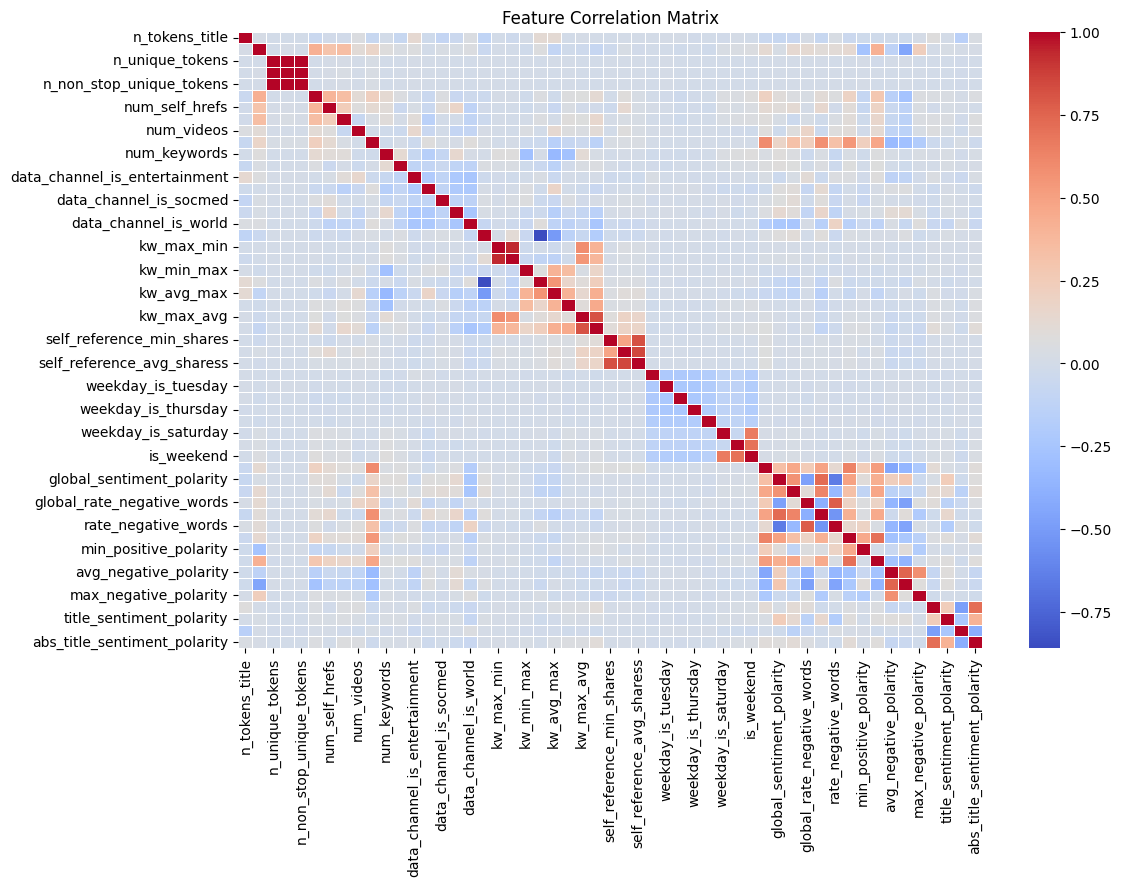

In [11]:
import seaborn as sns

# Compute correlation matrix
correlation_matrix = df_standardized.corr()

# Identify highly correlated pairs
high_corr_features = correlation_matrix.abs().stack().reset_index()
high_corr_features = high_corr_features[high_corr_features["level_0"] != high_corr_features["level_1"]]
high_corr_features = high_corr_features[high_corr_features[0] > 0.8].sort_values(by=0, ascending=False)

print(high_corr_features.head(10))  # Top 10 most correlated feature pairs

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
X = df_standardized.to_numpy()
y = df_cleaned["popularity"].map({"low": 0, "medium": 1, "high": 2}).to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rms_errors_basic = []
model_params_basic = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rms_error = np.sqrt(mean_squared_error(y_test, y_pred))
    rms_errors_basic.append(rms_error)
    model_params_basic.append(model.coef_)
avg_rms_error_basic = np.mean(rms_errors_basic)
print(f"Average RMS Error (Basic Model): {avg_rms_error_basic}")

Average RMS Error (Basic Model): 0.8350929011330166


In [13]:
from sklearn.metrics import confusion_matrix, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Implementing a Stratified Model Based on K-Means Clustering

from sklearn.cluster import KMeans

# Perform K-Means Clustering (Using k=3 for stratification)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X)

# Create dictionaries to store results for each cluster
cluster_rms_errors = {}
cluster_conf_matrices = {}
cluster_model_params = {}

# Train separate models within each cluster
for cluster_id in range(k):
    # Select data for the current cluster
    cluster_indices = np.where(clusters == cluster_id)[0]
    X_cluster = X[cluster_indices]
    y_cluster = y[cluster_indices]

    # Perform cross-validation within the cluster
    cluster_rms_errors_list = []
    cluster_conf_matrices_list = []
    cluster_model_params_list = []

    for train_index, test_index in KFold(n_splits=5, shuffle=True, random_state=42).split(X_cluster):
        X_train, X_test = X_cluster[train_index], X_cluster[test_index]
        y_cluster = y[cluster_indices]
        y_train, y_test = y_cluster[train_index], y_cluster[test_index]

        model_cluster = LinearRegression()
        model_cluster.fit(X_train, y_train)

        y_pred_cluster = np.round(model_cluster.predict(X_test))
        y_pred_cluster = np.clip(y_pred_cluster, 0, 2)

        rms_error_cluster = np.sqrt(mean_squared_error(y_test, y_pred_cluster))
        cluster_rms_errors_list.append(rms_error_cluster)
        cluster_model_params_list.append(model_cluster.coef_)

        cluster_conf_matrices_list.append(confusion_matrix(y_test, y_pred_cluster))

    # Store results for this cluster
    cluster_rms_errors[cluster_id] = np.mean(cluster_rms_errors_list)
    cluster_model_params[cluster_id] = cluster_model_params_list
    cluster_conf_matrices[cluster_id] = np.sum(cluster_conf_matrices_list, axis=0)

# Aggregate results across all clusters
avg_rms_error_stratified = np.mean(list(cluster_rms_errors.values()))
final_conf_matrix_stratified = np.sum(list(cluster_conf_matrices.values()), axis=0)

# Display results
print(f"Average RMS Error (Stratified Model): {avg_rms_error_stratified}")
print("\nFinal Confusion Matrix (Stratified Model):")
print(final_conf_matrix_stratified)

Average RMS Error (Stratified Model): 0.8008456515021942

Final Confusion Matrix (Stratified Model):
[[  483 11752   189]
 [  198 13294   773]
 [   74 11338  1543]]


In [14]:
#part (c)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define regularization parameters to test
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]

# Dictionary to store results for Ridge and Lasso
ridge_results = {}
lasso_results = {}

# Train Ridge Regression with different regularization strengths
for alpha in alpha_values:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)

    y_pred_ridge = np.round(ridge_model.predict(X_test))
    y_pred_ridge = np.clip(y_pred_ridge, 0, 2)

    rms_error_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    ridge_results[alpha] = (rms_error_ridge, np.linalg.norm(ridge_model.coef_), confusion_matrix(y_test, y_pred_ridge))

# Train Lasso Regression with different regularization strengths
for alpha in alpha_values:
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train, y_train)

    y_pred_lasso = np.round(lasso_model.predict(X_test))
    y_pred_lasso = np.clip(y_pred_lasso, 0, 2)

    rms_error_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    lasso_results[alpha] = (rms_error_lasso, np.linalg.norm(lasso_model.coef_), confusion_matrix(y_test, y_pred_lasso))

# Find the best Ridge and Lasso models based on lowest RMS error
best_ridge_alpha = min(ridge_results, key=lambda a: ridge_results[a][0])
best_lasso_alpha = min(lasso_results, key=lambda a: lasso_results[a][0])

# Retrieve best results
best_ridge_rms, best_ridge_norm, best_ridge_conf_matrix = ridge_results[best_ridge_alpha]
best_lasso_rms, best_lasso_norm, best_lasso_conf_matrix = lasso_results[best_lasso_alpha]

# Determine which model performed better
if best_ridge_rms < best_lasso_rms:
    best_model = "Ridge"
    best_rms = best_ridge_rms
    best_norm = best_ridge_norm
    best_conf_matrix = best_ridge_conf_matrix
    best_alpha = best_ridge_alpha
else:
    best_model = "Lasso"
    best_rms = best_lasso_rms
    best_norm = best_lasso_norm
    best_conf_matrix = best_lasso_conf_matrix
    best_alpha = best_lasso_alpha

# Display results
best_model, best_alpha, best_rms, best_norm, best_conf_matrix


('Lasso',
 0.001,
 0.7937833880193464,
 0.4448586360475882,
 array([[  57, 2398,   30],
        [  23, 2705,  125],
        [   5, 2310,  276]]))

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, mean_squared_error
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rms_errors_rf = []
conf_matrices_rf = []
model_params_rf = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = RandomForestClassifier(n_estimators=50, random_state=42, max_depth = 5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rms_error = np.sqrt(mean_squared_error(y_test, y_pred))
    rms_errors_rf.append(rms_error)
    conf_matrices_rf.append(confusion_matrix(y_test, y_pred))
    model_params_rf.append(model.feature_importances_)

avg_rms_error_rf = np.mean(rms_errors_rf)
final_conf_matrix_rf = np.sum(conf_matrices_rf, axis=0)
print (f"Average RMS Error (Random Forest): {avg_rms_error_rf}")
print("\nFinal Confusion Matrix (Random Forest):")
print(final_conf_matrix_rf)

Average RMS Error (Random Forest): 0.9249701591974423

Final Confusion Matrix (Random Forest):
[[6027 3901 2496]
 [3775 5862 4628]
 [1850 4231 6874]]


part 4a

In [16]:
import numpy as np

#Parameters
N = 39644  
p = 53     # num of features
k_folds = 5
N_train_per_fold = (4/5) * N
N_val_per_fold = (1/5) * N
N_train_3c = 0.8 * N
N_test_3c = 0.2 * N

# Cluster sizes for 3(b) for k=3
k_clusters = 3
N_per_cluster = N / k_clusters  # Approx samples per cluster
N_train_per_cluster_per_fold = (4/5) * N_per_cluster

# Random Forest parameters for 3(d)
n_trees = 50
max_depth = 5
n_features_per_split = int(np.sqrt(p))  # Approx sqrt(p) features per split

# RMS Errors
rms_errors = {
    "3a": 0.8351,  # Basic Linear Regression
    "3b": 0.8073,  # Stratified Linear Regression
    "3c": 0.7938,  # Lasso Regression
    "3d": 0.9249   # Random Forest
}

# stores flops
flops = {}

# 3(a) - Basic Linear Regression
flops_3a_train_per_fold = (2 * N_train_per_fold * p**2) + (2/3 * p**3) + (2 * N_train_per_fold * p) + (2 * p**2)
flops_3a_train = k_folds * flops_3a_train_per_fold

# Inference flops
flops_3a_inference_per_sample = 2 * p
flops_3a_inference_per_fold = N_val_per_fold * flops_3a_inference_per_sample
flops_3a_inference = k_folds * flops_3a_inference_per_fold

# Total flops for 3(a)
flops["3a"] = flops_3a_train + flops_3a_inference

# 3(b) - Stratified Linear Regression with K-Means (k=3)
# K-Means flops
max_iters_kmeans = 100
flops_kmeans_distances = k_clusters * N * (3 * p)  # Distance computation
flops_kmeans_assignments = k_clusters * N  # Cluster assignments
flops_kmeans_centroid_update = k_clusters * (N_per_cluster * p * 2)  # Centroid updates
flops_kmeans_per_iter = flops_kmeans_distances + flops_kmeans_assignments + flops_kmeans_centroid_update
flops_kmeans = max_iters_kmeans * flops_kmeans_per_iter

# Training Linear Regression per cluster
flops_3b_train_per_fold_per_cluster = (2 * N_train_per_cluster_per_fold * p**2) + (2/3 * p**3) + \
                                      (2 * N_train_per_cluster_per_fold * p) + (2 * p**2)
flops_3b_train = k_clusters * k_folds * flops_3b_train_per_fold_per_cluster

# Inference
flops_3b_inference = flops_3a_inference

# Total flops for 3(b)
flops["3b"] = flops_kmeans + flops_3b_train + flops_3b_inference

# 3(c) Lasso Regression (alpha=0.001)
# Training flops approx.
max_iters_lasso = 100
flops_lasso_per_iter = 2 * N_train_3c * p
flops_3c_train = max_iters_lasso * flops_lasso_per_iter

# Inference flops
flops_3c_inference_per_sample = 2 * p
flops_3c_inference = N_test_3c * flops_3c_inference_per_sample

# Total flops for 3(c)
flops["3c"] = flops_3c_train + flops_3c_inference

# 3(d) - Random Forest
max_nodes_per_tree = 2**max_depth - 1  # for depth=5
flops_per_split = (N_train_per_fold * np.log2(N_train_per_fold)) + (2 * N_train_per_fold)
flops_per_tree = max_nodes_per_tree * n_features_per_split * flops_per_split
flops_3d_train = n_trees * flops_per_tree

# Inference flops
flops_3d_inference_per_sample = max_depth * n_features_per_split * n_trees  # Traversing each tree
flops_3d_inference_per_fold = N_val_per_fold * flops_3d_inference_per_sample
flops_3d_inference = k_folds * flops_3d_inference_per_fold

# Total flops for 3(d)
flops["3d"] = flops_3d_train + flops_3d_inference

# Display Results
print("flops for Each Model:")
for part in flops:
    print(f"{part}: {int(flops[part]):,}")

print("\nComparison of flops vs RMS Error:")
print("| Model                     | Total flops       | RMS Error |")
print("|---------------------------|-------------------|-----------|")
for part in flops:
    print(f"| {part} - {'Basic LR' if part == '3a' else 'Stratified LR' if part == '3b' else 'Lasso' if part == '3c' else 'Random Forest':<15} | {int(flops[part]):<17,} | {rms_errors[part]:<9} |")

flops for Each Model:
3a: 912,415,634
3b: 3,236,602,728
3c: 337,021,572
3d: 5,903,033,527

Comparison of flops vs RMS Error:
| Model                     | Total flops       | RMS Error |
|---------------------------|-------------------|-----------|
| 3a - Basic LR        | 912,415,634       | 0.8351    |
| 3b - Stratified LR   | 3,236,602,728     | 0.8073    |
| 3c - Lasso           | 337,021,572       | 0.7938    |
| 3d - Random Forest   | 5,903,033,527     | 0.9249    |


part 4b

In [17]:
# analysis for 3a

model_params_basic = np.array(model_params_basic)
param_means_basic = np.mean(model_params_basic, axis=0)
param_stds_basic = np.std(model_params_basic, axis=0)

print("Basic Model: Mean of Parameters Across Folds")
print(param_means_basic)
print("\nBasic Model: Standard Deviation of Parameters Across Folds")
print(param_stds_basic)

# analysis for 3b
# analyze parameter stability
for cluster_id, params in cluster_model_params.items():
    params = np.array(params)
    param_means = np.mean(params, axis=0)
    param_stds = np.std(params, axis=0)

    print(f"\nStratified Model (Cluster {cluster_id}): Mean of Parameters Across Folds")
    print(param_means)
    print(f"\nStratified Model (Cluster {cluster_id}): Standard Deviation of Parameters Across Folds")
    print(param_stds)

# analysis for 3c
print(f"Norm of Best Lasso Model Parameters: {best_lasso_norm}")
print(f"Norm of Best Ridge Model Parameters: {best_ridge_norm}")


# analysis for 3d
model_params_rf = np.array(model_params_rf)
param_means_rf = np.mean(model_params_rf, axis=0)
param_stds_rf = np.std(model_params_rf, axis=0)

print("\nRandom Forest: Mean Feature Importances Across Folds")
print(param_means_rf)
print("\nRandom Forest: Standard Deviation of Feature Importances Across Folds")
print(param_stds_rf)

Basic Model: Mean of Parameters Across Folds
[-2.83672854e-05  2.37528002e-02 -4.12153662e-01  1.02113660e+00
 -5.18254797e-01  3.53662381e-02 -2.80129776e-02  2.54899416e-03
 -8.18350910e-04 -4.68954589e-02  2.72884457e-02  1.59064179e-02
 -5.42890561e-02  4.02263574e-02  9.14068997e-02  1.02718530e-01
 -2.15905065e-02  4.92446517e-02  5.46955996e-02 -6.28644850e-02
 -1.03778370e-02 -1.44857048e-02 -3.19548535e-02 -3.80395422e-02
 -2.20895566e-01  3.62716931e-01  6.01054804e-03  5.12596799e-03
  2.48746414e-02 -3.84914827e-04 -2.08097379e-02 -2.05884905e-02
 -1.45955176e-02  1.54305043e-02  3.61275147e-02  3.08190741e-02
  4.89686021e-02  3.58605159e-02 -1.11342109e-02 -7.71812169e-03
  1.28203333e-02  2.96597626e-02 -9.20032918e-03  2.63009638e-03
 -1.47874741e-02 -9.47920331e-03 -1.16956261e-02  6.51712827e-03
  5.48599499e-03  1.41431212e-02  1.54458331e-02  2.14574631e-02
  2.65812164e-03]

Basic Model: Standard Deviation of Parameters Across Folds
[0.00076902 0.00373853 0.1325155